# 03 — Results Analysis 2

**Repository:** `stochastic-physics-simulations`  
**Notebook:** Full analysis of Monte Carlo simulation results across all state points.

---

This notebook reproduces and extends the results from the thesis simulations:
NVT Monte Carlo of **864 particles** over the density range **0.05 ≤ ρ* ≤ 0.88**
and five values of the thermal de Broglie wavelength **λ_B = 0.0, 0.226, 0.473, 0.670, 1.148**,
corresponding to the de Boer quanticity parameter for neon, deuterium, hydrogen and helium.

1. Simulation data — loading and validation
2. Pair interaction potential family (effect of quanticity)
3. Collision parameters ⟨s⟩ and ⟨l⟩ vs. density
4. Compressibility factor Z vs. density
5. Internal energy — MC vs. theoretical reference
6. Summary across all state points

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import math, warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'lines.linewidth': 2.0,
    'lines.markersize': 6,
})

# color per λ_B value
LB_VALUES  = [0.0, 0.22608, 0.47339, 0.67019, 1.14789]
LB_LABELS  = [r'$\lambda_B^* = 0.0$  (classical)',
              r'$\lambda_B^* = 0.226$',
              r'$\lambda_B^* = 0.473$',
              r'$\lambda_B^* = 0.670$',
              r'$\lambda_B^* = 1.148$']
COLORS     = ['steelblue', 'darkorange', 'seagreen', 'tomato', 'mediumpurple']
MARKERS    = ['o', 's', '^', 'D', 'v']

pi = math.acos(-1.0)
print("Setup complete.")
print(f"λ_B values: {LB_VALUES}")

Setup complete.
λ_B values: [0.0, 0.22608, 0.47339, 0.67019, 1.14789]


---
## 1. Simulation Data

All results come from NVT Monte Carlo simulations of N = 864 particles at T* = 1.5.
Total moves: 10⁷ (equilibration) + 6×10⁷ (production).
Acceptance rate tuned to 30–50% by adjusting DISPL.

The tables below reproduce Tables 7.1–7.5 of the thesis.

In [2]:
# ── Table 7.1: Classical system λ_B = 0.0 ────────────────────────────────────
data_lb0 = {
    'rho':  [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88],
    'nuR':  [0.10693, 0.19834, 0.43653, 0.75855, 1.16807, 1.72722,
             2.46241, 3.54965, 4.99065, 6.63619],
    'nuA':  [0.05993, 0.12437, 0.28281, 0.49796, 0.75151, 1.07873,
             1.45530, 1.98530, 2.54640, 3.12131],
    's':    [0.99500, 0.99760, 0.99796, 0.99889, 0.99894, 0.99911,
             0.99891, 0.99908, 0.99880, 0.99877],
    'l':    [1.06525, 1.06561, 1.06478, 1.06309, 1.06286, 1.06221,
             1.06235, 1.06068, 1.06045, 1.05936],
    'Z':    [1.08913, 1.13684, 1.28172, 1.47822, 1.77090, 2.21443,
             2.91363, 4.01722, 5.78428, 7.95640],
    'Z_th': [1.11191, 1.23966, 1.55316, 1.96671, 2.51800, 3.26243,
             4.28342, 5.71020, 7.74969, 10.0466],
    'Z_th_label': 'Z_CS'
}

# ── Table 7.2: λ_B = 0.22608 ─────────────────────────────────────────────────
data_lb1 = {
    'rho':  [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88],
    'nuR':  [0.02136, 0.04002, 0.07618, 0.12729, 0.20894, 0.33954,
             0.56534, 1.01719, 2.48861, 7.68425],
    'nuA':  [0.00904, 0.01928, 0.03715, 0.06153, 0.10007, 0.15506,
             0.24369, 0.44160, 0.90554, 2.59945],
    's':    [1.01866, 1.02102, 1.02140, 1.02132, 1.02170, 1.02197,
             1.02176, 1.02181, 1.02184, 1.02176],
    'l':    [1.09040, 1.08868, 1.08851, 1.08830, 1.08803, 1.08731,
             1.08634, 1.08626, 1.08406, 1.08343],
    'Z':    [1.02492, 1.04162, 1.07828, 1.13203, 1.21907, 1.37366,
             1.65535, 2.25737, 4.26999, 11.54563],
    'Z_th': [1.15685, 1.34261, 1.82433, 2.50663, 3.48368, 4.90375,
             7.00763, 10.2008, 15.1968, 21.3459],
    'Z_th_label': 'Z_QHS'
}

# ── Table 7.3: λ_B = 0.47339 ─────────────────────────────────────────────────
data_lb2 = {
    'rho':  [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88],
    'nuR':  [0.02034, 0.03385, 0.08468, 0.14197, 0.23453, 0.35917,
             0.63881, 1.32598, 4.10222, 2.15658],
    'nuA':  [0.01676, 0.02855, 0.06729, 0.11782, 0.18828, 0.28540,
             0.47235, 0.89546, 2.45786, 1.64205],
    's':    [1.03729, 1.03512, 1.03587, 1.03648, 1.03679, 1.03699,
             1.03710, 1.03674, 1.03667, 1.03693],
    'l':    [1.09785, 1.10347, 1.10028, 1.10008, 1.09867, 1.09825,
             1.09708, 1.09659, 1.09470, 1.09776],
    'Z':    [1.00560, 1.00740, 1.02865, 1.03672, 1.07603, 1.12359,
             1.30223, 1.82257, 4.27153, 1.90825],
    'Z_th': [1.20815, 1.46503, 2.17353, 3.25784, 4.93371, 7.56269,
             11.7699, 18.6766, 30.3814, 45.8582],
    'Z_th_label': 'Z_QHS'
}

# ── Table 7.4: λ_B = 0.67019 ─────────────────────────────────────────────────
data_lb3 = {
    'rho':  [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88],
    'nuR':  [0.02267, 0.04038, 0.08760, 0.14741, 0.23672, 0.39835,
             0.70801, 1.44928, 4.90684, 2.20926],
    'nuA':  [0.02411, 0.04616, 0.11334, 0.19245, 0.30387, 0.49149,
             0.83613, 1.60296, 4.82446, 2.77566],
    's':    [1.03869, 1.03932, 1.04194, 1.04259, 1.04208, 1.04194,
             1.04242, 1.04274, 1.04214, 1.04266],
    'l':    [1.10186, 1.10473, 1.10210, 1.10173, 1.10209, 1.10179,
             1.09998, 1.09842, 1.09827, 1.10032],
    'Z':    [0.99367, 0.98109, 0.92955, 0.87783, 0.81525, 0.73512,
             0.61948, 0.47748, 0.61270, -0.57205],
    'Z_th': [1.25061, 1.57028, 2.49619, 4.00104, 6.46440, 10.5447,
             17.4081, 29.1587, 49.6527, 76.9558],
    'Z_th_label': 'Z_QHS'
}

# ── Table 7.5: λ_B = 1.14789 ─────────────────────────────────────────────────
data_lb4 = {
    'rho':  [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88],
    'nuR':  [0.02403, 0.04452, 0.09685, 0.16463, 0.25562, 0.43391,
             0.69603, 2.00880, 6.87243, 2.48917],
    'nuA':  [0.06498, 0.12285, 0.28812, 0.47760, 0.79360, 1.30926,
             2.05482, 5.16350, 16.38447, 7.45465],
    's':    [1.03869, 1.04821, 1.04978, 1.04937, 1.04776, 1.04881,
             1.04840, 1.04936, 1.04926, 1.04957],
    'l':    [1.10556, 1.10577, 1.10379, 1.10345, 1.10458, 1.10322,
             1.10276, 1.10020, 1.09907, 1.10164],
    'Z':    [0.90181, 0.81324, 0.54686, 0.25807, -0.27500, -1.07201,
             -2.21751, -6.48312, -21.61270, -10.73963],
    'Z_th': [None]*10,
    'Z_th_label': 'Z_QHS'
}

ALL_DATA = [data_lb0, data_lb1, data_lb2, data_lb3, data_lb4]

# Table 7.1 
df0 = pd.DataFrame({k: v for k, v in data_lb0.items() if k != 'Z_th_label'})
df0.columns = ['ρ*', 'ν*_R', 'ν*_A', '⟨s*⟩', '⟨l*⟩', 'Z (MC)', 'Z_CS']
print("Table 7.1 — Classical system (λ_B = 0.0)")
print(df0.to_string(index=False, float_format='{:.5f}'.format))

Table 7.1 — Classical system (λ_B = 0.0)
     ρ*    ν*_R    ν*_A    ⟨s*⟩    ⟨l*⟩  Z (MC)     Z_CS
0.05000 0.10693 0.05993 0.99500 1.06525 1.08913  1.11191
0.10000 0.19834 0.12437 0.99760 1.06561 1.13684  1.23966
0.20000 0.43653 0.28281 0.99796 1.06478 1.28172  1.55316
0.30000 0.75855 0.49796 0.99889 1.06309 1.47822  1.96671
0.40000 1.16807 0.75151 0.99894 1.06286 1.77090  2.51800
0.50000 1.72722 1.07873 0.99911 1.06221 2.21443  3.26243
0.60000 2.46241 1.45530 0.99891 1.06235 2.91363  4.28342
0.70000 3.54965 1.98530 0.99908 1.06068 4.01722  5.71020
0.80000 4.99065 2.54640 0.99880 1.06045 5.78428  7.74969
0.88000 6.63619 3.12131 0.99877 1.05936 7.95640 10.04660


---
## 2. Pair Interaction Potential — Effect of Quanticity

The effective potential shifts with λ_B as the quantum correction broadens and softens
the repulsive core. The minimum moves outward and the cutoff radius increases,
consistent with the interpretation that quantum effects increase the *effective size*
of the particles.

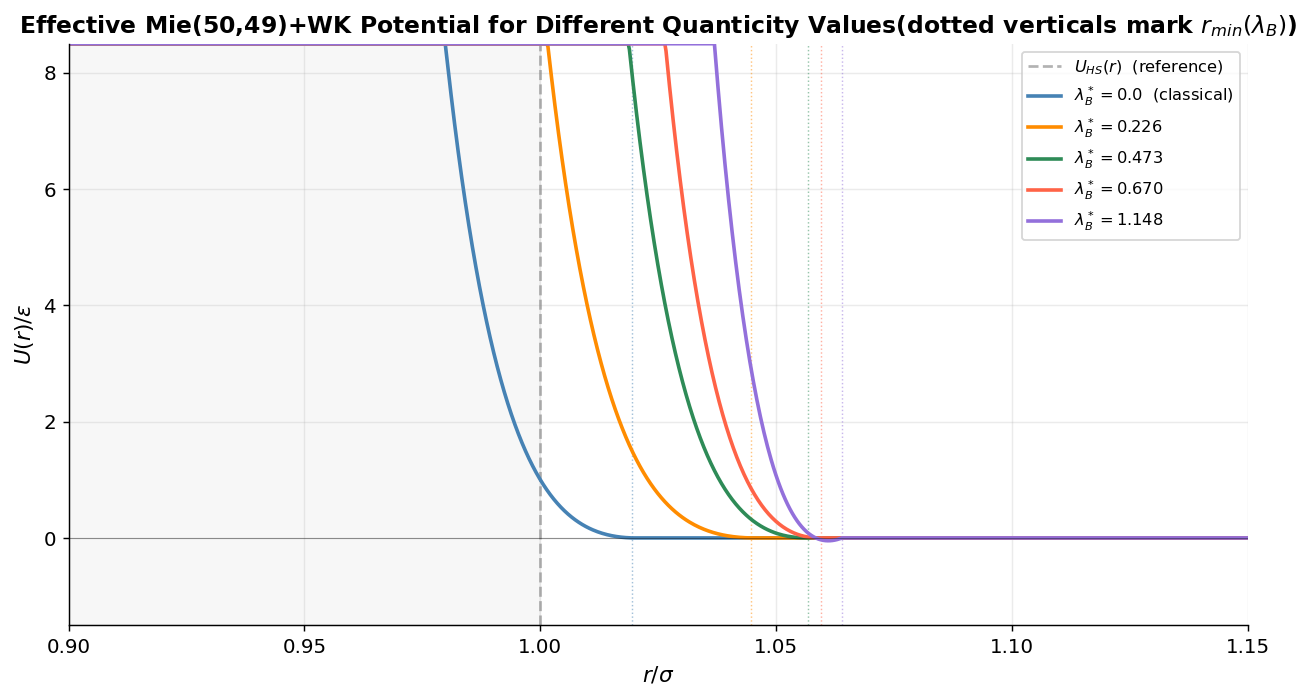

Potential minimum positions r_min(λ_B):
  λ_B = 0.00000  →  r_min = 1.019400 σ
  λ_B = 0.22608  →  r_min = 1.044625 σ
  λ_B = 0.47339  →  r_min = 1.056767 σ
  λ_B = 0.67019  →  r_min = 1.059500 σ
  λ_B = 1.14789  →  r_min = 1.063940 σ


In [3]:
# thesis Figure 6.2 
def xmin_poly(lb):
    """Polynomial fit for the potential minimum position as a function of λ_B."""
    lb2 = lb**2;  lb3 = lb**3
    return 1.0194 + 0.14983*lb - 0.18698*lb2 + 0.078628*lb3

def uwks(r_arr, lb):
    """
    Effective Mie(50,49) + WK potential, truncated and shifted at r_min.
    Returns u(r)/ε.
    """
    lb2  = lb**2
    CTE  = 50.0 * (50.0/49.0)**49
    CWK  = lb2 / (24.0 * pi)
    rmin = xmin_poly(lb)

    r    = np.asarray(r_arr, dtype=float)
    u    = np.zeros_like(r)
    mask = r < rmin

    # Mie(50,49) part
    rm   = r[mask]
    uhs  = CTE * (rm**(-50) - rm**(-49)) + 1.0
    # Laplacian correction: nabla²U = CTE*(2450*r^-52 - 2352*r^-51)
    uwk  = CTE * CWK * (2450.0*rm**(-52) - 2352.0*rm**(-51))
    # shift so u(rmin) = 0
    rmin_uhs = CTE * (rmin**(-50) - rmin**(-49)) + 1.0
    rmin_uwk = CTE * CWK * (2450.0*rmin**(-52) - 2352.0*rmin**(-51))
    u[mask] = uhs + uwk - rmin_uhs - rmin_uwk
    return u

# Hard-sphere reference
def u_hs(r_arr):
    r = np.asarray(r_arr)
    u = np.zeros_like(r, dtype=float)
    u[r < 1.0] = np.inf
    return u

r = np.linspace(0.90, 1.15, 1000)

fig, ax = plt.subplots(figsize=(10, 5.5))

# Hard sphere reference
ax.axvline(1.0, color='gray', linewidth=1.5, linestyle='--',
           alpha=0.6, label=r'$U_{HS}(r)$  (reference)')
ax.axvspan(0.88, 1.0, alpha=0.06, color='gray')

for lb, label, color in zip(LB_VALUES, LB_LABELS, COLORS):
    u = uwks(r, lb)
    u_clipped = np.clip(u, -1.5, 8.5)
    rmin = xmin_poly(lb)
    ax.plot(r, u_clipped, color=color, linewidth=2.0, label=label)
    ax.axvline(rmin, color=color, linewidth=0.8, linestyle=':', alpha=0.5)

ax.axhline(0, color='black', linewidth=0.6, linestyle='-', alpha=0.4)
ax.set_xlabel(r'$r/\sigma$')
ax.set_ylabel(r'$U(r)/\epsilon$')
ax.set_title('Effective Mie(50,49)+WK Potential for Different Quanticity Values'
             r'(dotted verticals mark $r_{min}(\lambda_B)$)', fontweight='bold')
ax.set_xlim(0.90, 1.15)
ax.set_ylim(-1.5, 8.5)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print("Potential minimum positions r_min(λ_B):")
for lb in LB_VALUES:
    print(f"  λ_B = {lb:.5f}  →  r_min = {xmin_poly(lb):.6f} σ")

---
## 3. Collision Parameters ⟨s⟩ and ⟨l⟩ vs. Density

The **mean repulsive diameter ⟨s⟩** and **mean attractive range ⟨l⟩** characterize the
effective interaction geometry. They are computed from g(r) via the virial integrals
and provide a direct measure of how quantum corrections alter the effective particle size.

Key observations from the thesis:
- ⟨s⟩ increases with λ_B — quantum corrections effectively *enlarge* the particles
- ⟨l⟩ also increases with λ_B, reflecting the broader range of attraction
- Both parameters are nearly density-independent (plateau behavior)

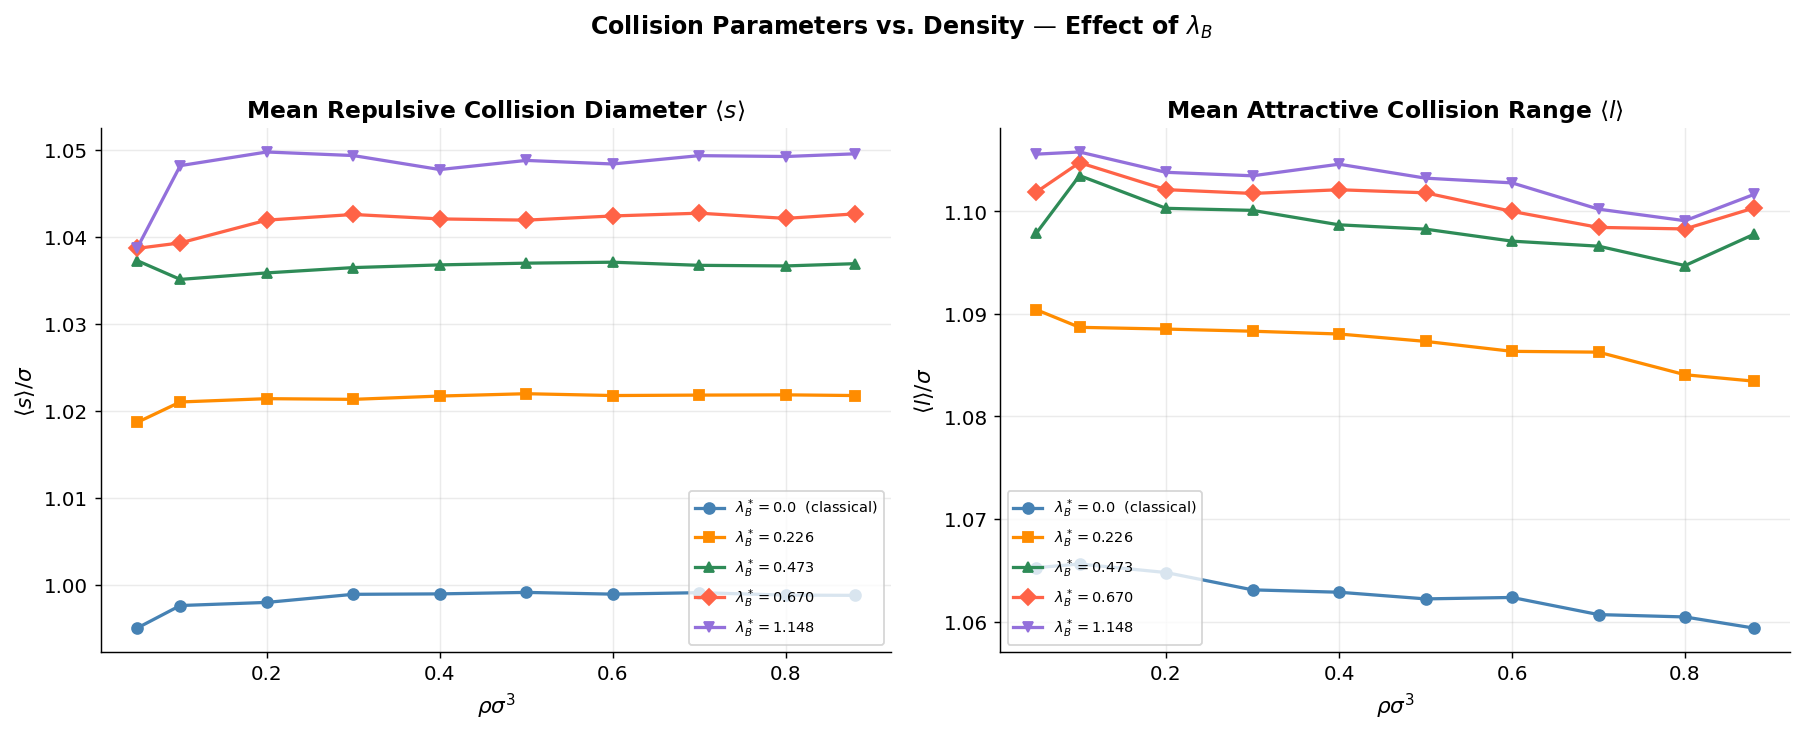

Mean values of ⟨s⟩ and ⟨l⟩ averaged over all densities:
       λ_B    ⟨s⟩ mean    ⟨l⟩ mean
  -----------------------------------
   0.00000     0.99831     1.06266
   0.22608     1.02132     1.08713
   0.47339     1.03660     1.09847
   0.67019     1.04165     1.10113
   1.14789     1.04792     1.10300


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for i, (data, lb, label, color, marker) in enumerate(
        zip(ALL_DATA, LB_VALUES, LB_LABELS, COLORS, MARKERS)):

    rho = np.array(data['rho'])
    s   = np.array(data['s'])
    l   = np.array(data['l'])

    axes[0].plot(rho, s, color=color, marker=marker, linewidth=1.8,
                 markersize=6, label=label)
    axes[1].plot(rho, l, color=color, marker=marker, linewidth=1.8,
                 markersize=6, label=label)

axes[0].set_xlabel(r'$\rho\sigma^3$')
axes[0].set_ylabel(r'$\langle s \rangle / \sigma$')
axes[0].set_title(r'Mean Repulsive Collision Diameter $\langle s \rangle$',
                  fontweight='bold')
axes[0].legend(fontsize=8, loc='lower right')

axes[1].set_xlabel(r'$\rho\sigma^3$')
axes[1].set_ylabel(r'$\langle l \rangle / \sigma$')
axes[1].set_title(r'Mean Attractive Collision Range $\langle l \rangle$',
                  fontweight='bold')
axes[1].legend(fontsize=8, loc='lower left')

plt.suptitle(r'Collision Parameters vs. Density — Effect of $\lambda_B$',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# quantitative summary 
print("Mean values of ⟨s⟩ and ⟨l⟩ averaged over all densities:")
print(f"  {'λ_B':>8s}  {'⟨s⟩ mean':>10s}  {'⟨l⟩ mean':>10s}")
print("  " + "-"*35)
for data, lb in zip(ALL_DATA, LB_VALUES):
    print(f"  {lb:>8.5f}  {np.mean(data['s']):>10.5f}  {np.mean(data['l']):>10.5f}")

### Collision Frequencies ν*_R and ν*_A

At low λ_B, repulsive collisions dominate (ν_R > ν_A).
At high λ_B (0.670 and 1.148), the roles invert and attractive collisions
become more frequent — a signature of strong quantum effects softening the core.

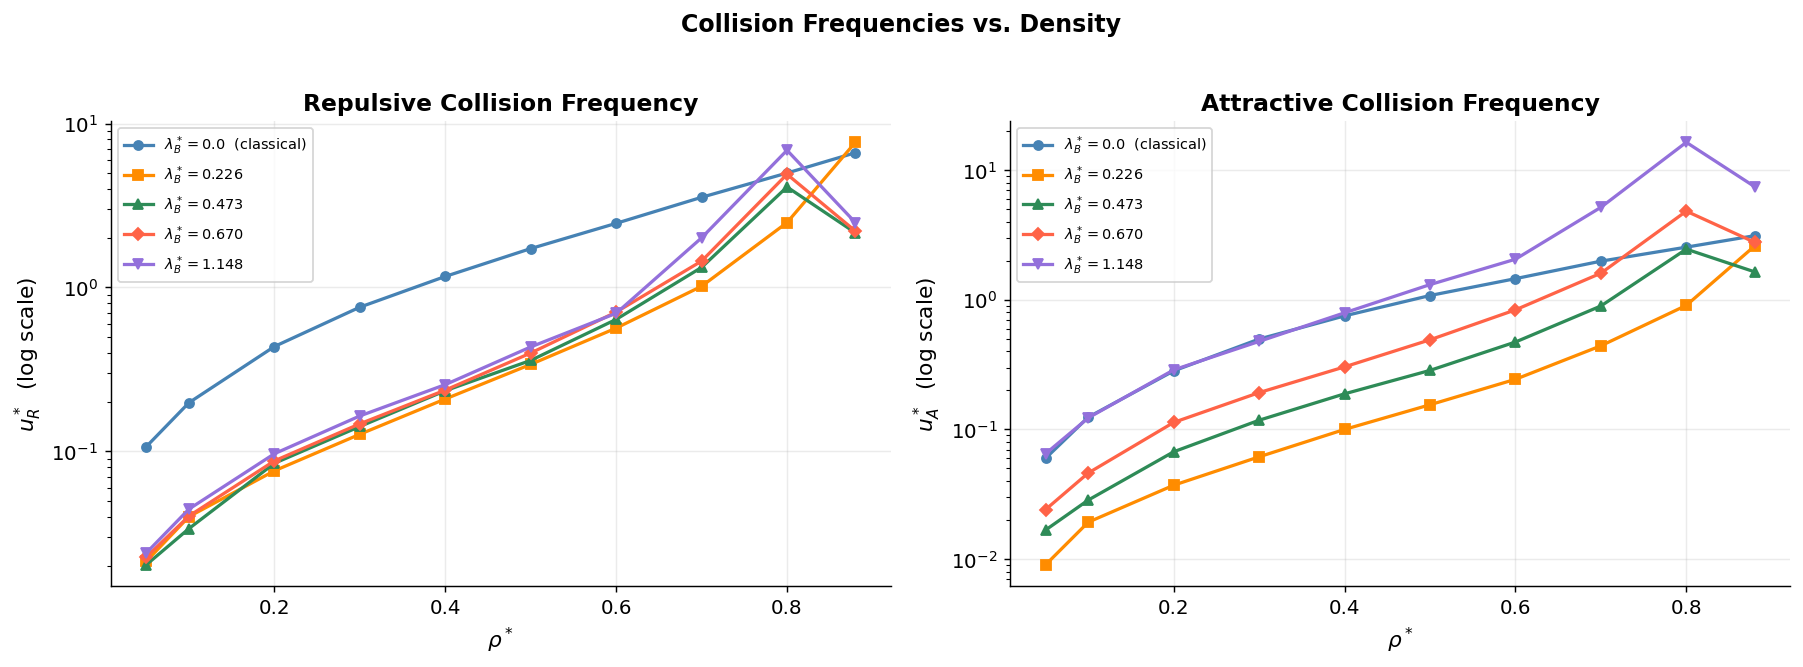

ν_R / ν_A ratio at ρ* = 0.50:
       λ_B         ν_R         ν_A     ratio      dominant
  -------------------------------------------------------
   0.00000     1.72722     1.07873     1.601     repulsive
   0.22608     0.33954     0.15506     2.190     repulsive
   0.47339     0.35917     0.28540     1.258     repulsive
   0.67019     0.39835     0.49149     0.810  ATTRACTIVE ←
   1.14789     0.43391     1.30926     0.331  ATTRACTIVE ←


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for data, lb, label, color, marker in zip(
        ALL_DATA, LB_VALUES, LB_LABELS, COLORS, MARKERS):
    rho = np.array(data['rho'])
    nuR = np.array(data['nuR'])
    nuA = np.array(data['nuA'])
    axes[0].semilogy(rho, nuR, color=color, marker=marker,
                     linewidth=1.8, markersize=5, label=label)
    axes[1].semilogy(rho, nuA, color=color, marker=marker,
                     linewidth=1.8, markersize=5, label=label)

axes[0].set_xlabel(r'$\rho^*$');  axes[0].set_ylabel(r'$u_R^*$  (log scale)')
axes[0].set_title('Repulsive Collision Frequency', fontweight='bold')
axes[0].legend(fontsize=8)

axes[1].set_xlabel(r'$\rho^*$');  axes[1].set_ylabel(r'$u_A^*$  (log scale)')
axes[1].set_title('Attractive Collision Frequency', fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Collision Frequencies vs. Density', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ratio ν_R / ν_A — highlight inversion
print("ν_R / ν_A ratio at ρ* = 0.50:")
print(f"  {'λ_B':>8s}  {'ν_R':>10s}  {'ν_A':>10s}  {'ratio':>8s}  {'dominant':>12s}")
print("  " + "-"*55)
for data, lb in zip(ALL_DATA, LB_VALUES):
    idx = data['rho'].index(0.50)
    nR  = data['nuR'][idx];  nA = data['nuA'][idx]
    ratio = nR/nA
    dom = 'repulsive' if ratio > 1 else 'ATTRACTIVE ←'
    print(f"  {lb:>8.5f}  {nR:>10.5f}  {nA:>10.5f}  {ratio:>8.3f}  {dom:>12s}")

---
## 4. Compressibility Factor Z vs. Density

$Z = PV/NkT$ measures the deviation from ideal-gas behavior.
For the classical system (λ_B = 0), Z increases monotonically with density.
As λ_B increases, Z *decreases* relative to the classical case and eventually
becomes negative at high λ_B and high density — indicating strong quantum
attraction dominating over repulsion.

The theoretical reference is the quantum hard-sphere equation of state
(Carnahan-Starling with effective packing fraction, Serna & Gil-Villegas 2016).

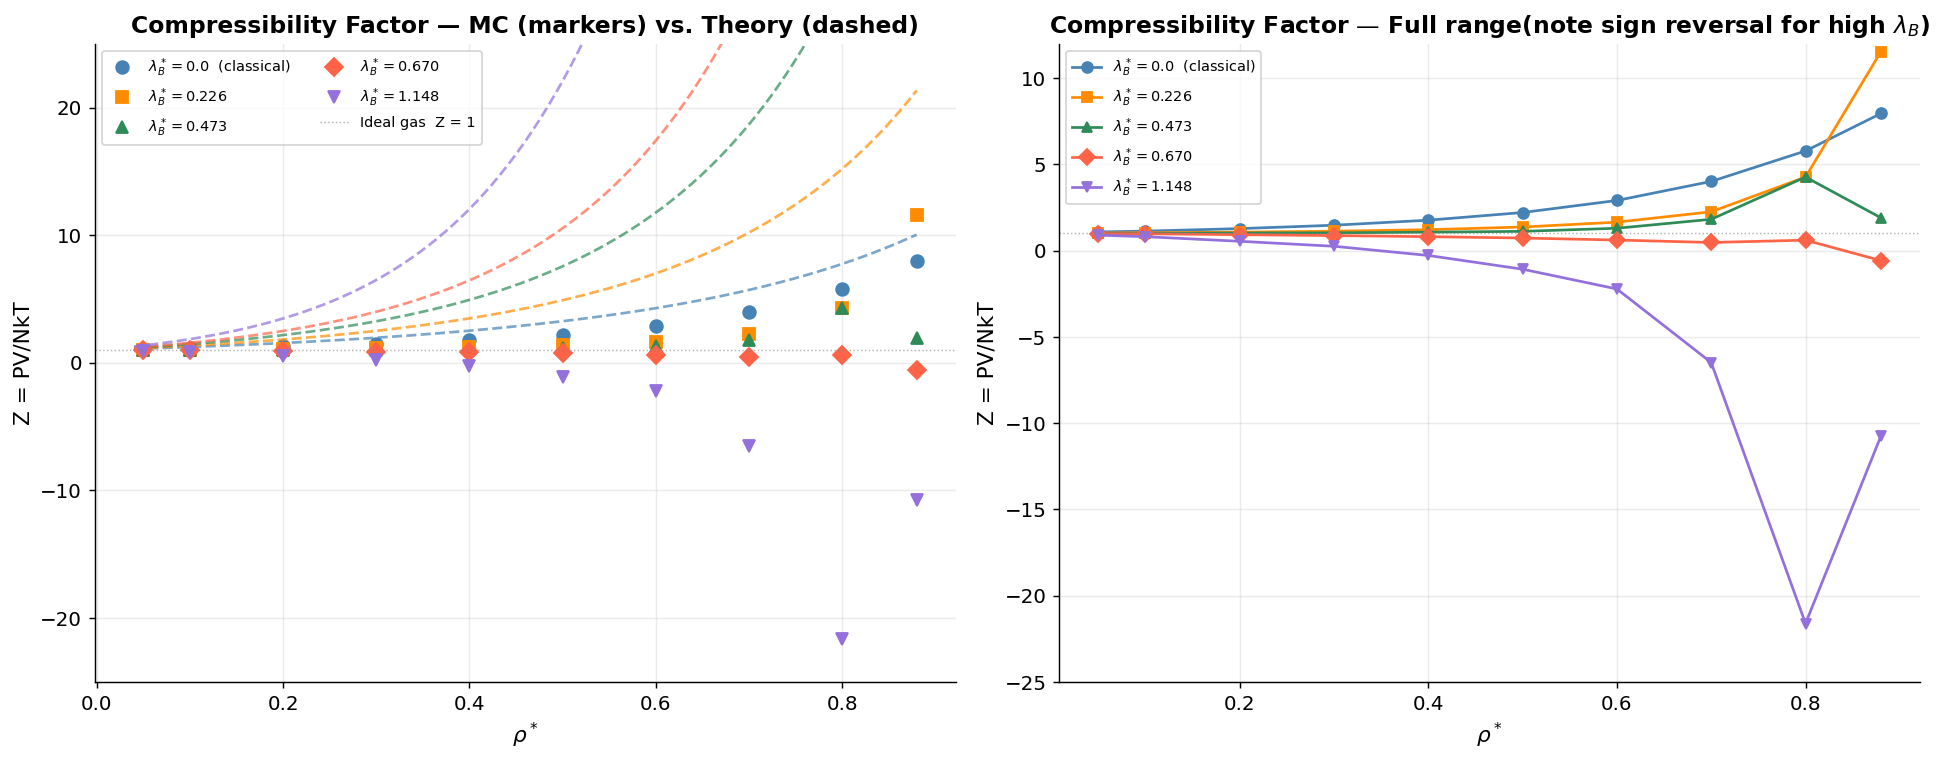

Z (MC) vs Z_QHS at ρ* = 0.40:
       λ_B      Z_MC     Z_QHS         Δ        Δ%
  --------------------------------------------------
   0.00000    1.7709    2.5180   -0.7471     29.7%
   0.22608    1.2191    3.4837   -2.2646     65.0%
   0.47339    1.0760    4.9337   -3.8577     78.2%
   0.67019    0.8153    6.4644   -5.6492     87.4%
   1.14789   -0.2750   12.0502  -12.3252    102.3%


In [6]:
# theoretical Z_QHS (Carnahan-Starling quantum mapping)
def Z_qhs(rho, lb):
    """Compressibility factor from quantum CS equation of state."""
    lb2 = lb**2
    et  = rho * pi / 6.0;  et2 = et**2
    d1  = 1.6593854484;  d2 = -1.0927115150;  d3 = -1.1188233921
    etq = (1.0 + d1*lb)*et + (d2*lb + d3*lb2)*et2
    etq2 = etq**2;  etq3 = etq2*etq
    detq3 = (1.0 - etq)**3
    return (1.0 + etq + etq2 - etq3) / detq3

# Z vs rho 
rho_th = np.linspace(0.04, 0.88, 200)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for data, lb, label, color, marker in zip(
        ALL_DATA, LB_VALUES, LB_LABELS, COLORS, MARKERS):

    rho = np.array(data['rho'])
    Z   = np.array(data['Z'])
    Z_t = [Z_qhs(r, lb) for r in rho_th]

    # MC points
    axes[0].plot(rho, Z, color=color, marker=marker, linewidth=0,
                 markersize=7, label=label)
    # theory lines
    axes[0].plot(rho_th, Z_t, color=color, linewidth=1.5, linestyle='--', alpha=0.7)

    # zoom: low-density region
    axes[1].plot(rho, Z, color=color, marker=marker, linewidth=1.5,
                 markersize=6, label=label)

axes[0].axhline(1.0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6,
                label='Ideal gas  Z = 1')
axes[0].set_xlabel(r'$\rho^*$');  axes[0].set_ylabel('Z = PV/NkT')
axes[0].set_title('Compressibility Factor — MC (markers) vs. Theory (dashed)',
                  fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)
axes[0].set_ylim(-25, 25)

axes[1].axhline(1.0, color='gray', linewidth=0.8, linestyle=':', alpha=0.6)
axes[1].set_xlabel(r'$\rho^*$');  axes[1].set_ylabel('Z = PV/NkT')
axes[1].set_title('Compressibility Factor — Full range'
                  r'(note sign reversal for high $\lambda_B$)', fontweight='bold')
axes[1].legend(fontsize=8);  axes[1].set_ylim(-25, 12)

plt.tight_layout()
plt.show()

# deviation MC vs theory 
print("Z (MC) vs Z_QHS at ρ* = 0.40:")
print(f"  {'λ_B':>8s}  {'Z_MC':>8s}  {'Z_QHS':>8s}  {'Δ':>8s}  {'Δ%':>8s}")
print("  " + "-"*50)
for data, lb in zip(ALL_DATA, LB_VALUES):
    idx   = data['rho'].index(0.40)
    z_mc  = data['Z'][idx]
    z_th  = Z_qhs(0.40, lb)
    delta = z_mc - z_th
    pct   = 100*abs(delta)/abs(z_th) if z_th != 0 else float('nan')
    print(f"  {lb:>8.5f}  {z_mc:>8.4f}  {z_th:>8.4f}  {delta:>8.4f}  {pct:>7.1f}%")

---
## 5. Internal Energy — MC vs. Theoretical Reference

Table 7.6 from the thesis compares MC results for ⟨U⟩/NkT across
three correction schemes:
- **WKS**: Mie(50,49) + Wigner-Kirkwood (shifted)
- **YS**: Mie(50,49) + Yoon-Scheraga correction
- **QHS**: Theoretical reference (quantum CS equation of state)

Key finding: the YS correction gives much better agreement with theory
than WKS for all λ_B values, while WKS shows an anomalous *decrease*
in internal energy with increasing quanticity.

In [7]:
# ── Table 7.6 data ───────────────────────────────────────────────────────────
rho_u = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.88]

# Classical Mie (λ_B = 0.0)
U_classical = [0.0036, 0.0077, 0.0179, 0.0313, 0.0493, 0.0735,
               0.1071, 0.1541, 0.2207, 0.2952]

# WK correction
U_WKS = {
    0.22608: [0.0041, 0.0087, 0.0204, 0.0365, 0.0580, 0.0883,
              0.1306, 0.1919, 0.2850, 0.3726],
    0.47339: [0.0037, 0.0080, 0.0187, 0.0335, 0.0541, 0.0833,
              0.1253, 0.1872, 0.2828, 0.2632],
    0.67019: [0.0032, 0.0070, 0.0167, 0.0299, 0.0484, 0.0750,
              0.1131, 0.1712, 0.2590, 0.2363],
    1.14789: [0.0023, 0.0050, 0.0118, 0.0214, 0.0351, 0.0544,
              0.0827, 0.1258, 0.1922, 0.1720],
}

# Yoon-Scheraga correction
U_YS = {
    0.22608: [0.0216, 0.0470, 0.1122, 0.2017, 0.3338, 0.5185,
              0.7900, 1.1816, 1.5314, 1.7645],
    0.47339: [0.0505, 0.1086, 0.2748, 0.5092, 0.8653, 1.3814,
              2.1086, 3.1082, 4.3072, 5.1893],
    0.67019: [0.0766, 0.1761, 0.4463, 0.8600, 1.4641, 2.3128,
              3.4172, 4.8075, 6.3884, 7.6745],
    1.14789: [0.1712, 0.3975, 1.0852, 2.0972, 3.4219, 5.0083,
              6.7825, 8.6578, 10.5068, 12.1416],
}

# Theoretical QHS energy
U_QHS = {
    0.22608: [0.0209, 0.0448, 0.1034, 0.1806, 0.2835, 0.4226,
              0.6141, 0.8835, 1.2730, 1.7185],
    0.47339: [0.0447, 0.0975, 0.2336, 0.4241, 0.6926, 1.0744,
              1.6232, 2.4219, 3.6009, 4.9527],
    0.67019: [0.0642, 0.1422, 0.3509, 0.6564, 1.1029, 1.7535,
              2.6945, 4.0326, 5.8625, 7.6682],
    1.14789: [None]*10,   # No theoretical prediction available
}

rho_u = np.array(rho_u)
print("Internal energy data loaded.")
print(f"λ_B values with data: {list(U_WKS.keys())}")

Internal energy data loaded.
λ_B values with data: [0.22608, 0.47339, 0.67019, 1.14789]


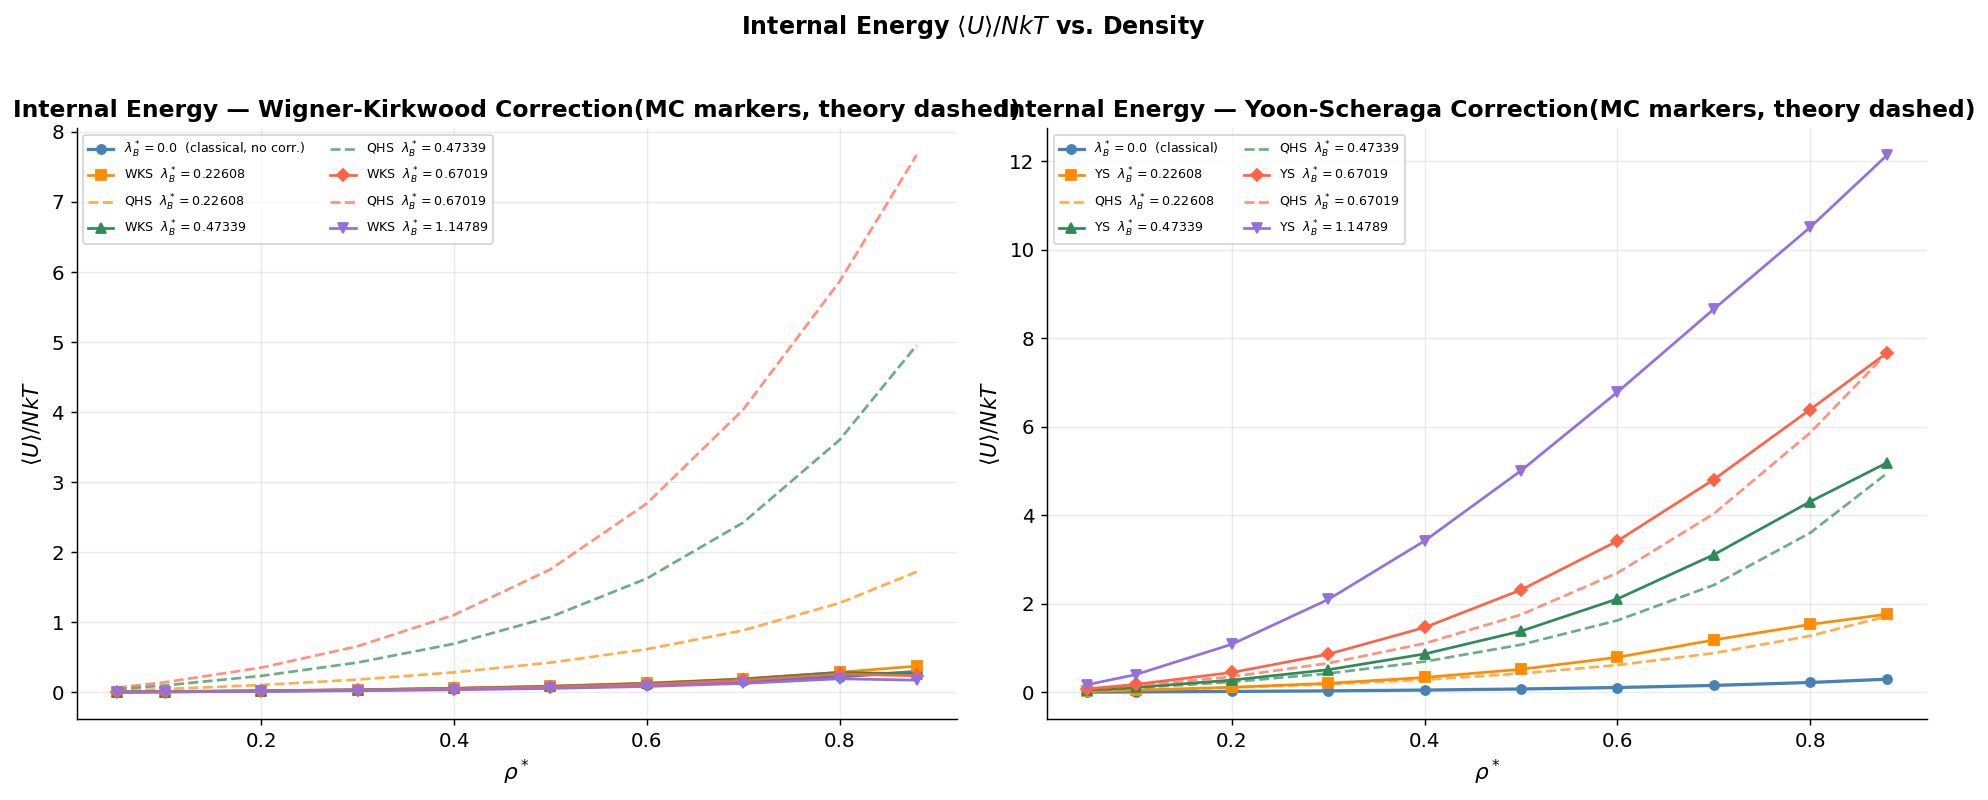

In [8]:
# thesis Figures 7.4 and 7.5
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
lb_list = [0.22608, 0.47339, 0.67019, 1.14789]
colors4 = ['darkorange', 'seagreen', 'tomato', 'mediumpurple']
markers4 = ['s', '^', 'D', 'v']

# Wigner-Kirkwood correction (Figure 7.4)
# classical baseline
axes[0].plot(rho_u, U_classical, color='steelblue', marker='o',
             linewidth=1.8, markersize=5,
             label=r'$\lambda_B^* = 0.0$  (classical, no corr.)')

for lb, color, marker in zip(lb_list, colors4, markers4):
    # MC WKS
    axes[0].plot(rho_u, U_WKS[lb], color=color, marker=marker,
                 linewidth=1.5, markersize=5,
                 label=fr'WKS  $\lambda_B^*={lb}$')
    # theory QHS
    u_th = U_QHS[lb]
    if any(v is not None for v in u_th):
        u_th_clean = [v for v in u_th if v is not None]
        rho_clean  = [r for r, v in zip(rho_u, u_th) if v is not None]
        axes[0].plot(rho_clean, u_th_clean, color=color, linewidth=1.5,
                     linestyle='--', alpha=0.7,
                     label=fr'QHS  $\lambda_B^*={lb}$')

axes[0].set_xlabel(r'$\rho^*$')
axes[0].set_ylabel(r'$\langle U \rangle / NkT$')
axes[0].set_title('Internal Energy — Wigner-Kirkwood Correction'
                  '(MC markers, theory dashed)', fontweight='bold')
axes[0].legend(fontsize=7, ncol=2)

# Yoon-Scheraga correction (Figure 7.5) 
axes[1].plot(rho_u, U_classical, color='steelblue', marker='o',
             linewidth=1.8, markersize=5,
             label=r'$\lambda_B^* = 0.0$  (classical)')

for lb, color, marker in zip(lb_list, colors4, markers4):
    axes[1].plot(rho_u, U_YS[lb], color=color, marker=marker,
                 linewidth=1.5, markersize=5,
                 label=fr'YS  $\lambda_B^*={lb}$')
    u_th = U_QHS[lb]
    if any(v is not None for v in u_th):
        u_th_clean = [v for v in u_th if v is not None]
        rho_clean  = [r for r, v in zip(rho_u, u_th) if v is not None]
        axes[1].plot(rho_clean, u_th_clean, color=color, linewidth=1.5,
                     linestyle='--', alpha=0.7,
                     label=fr'QHS  $\lambda_B^*={lb}$')

axes[1].set_xlabel(r'$\rho^*$')
axes[1].set_ylabel(r'$\langle U \rangle / NkT$')
axes[1].set_title('Internal Energy — Yoon-Scheraga Correction'
                  '(MC markers, theory dashed)', fontweight='bold')
axes[1].legend(fontsize=7, ncol=2)

plt.suptitle(r'Internal Energy $\langle U \rangle / NkT$ vs. Density',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# quantitative comparison: WKS vs YS vs QHS at ρ* = 0.50 
print("Internal energy comparison at ρ* = 0.50:")
print(f"  {'λ_B':>8s}  {'WKS':>8s}  {'YS':>8s}  {'QHS':>8s}  "
      f"{'ΔWK/QHS%':>10s}  {'ΔYS/QHS%':>10s}")
print("  " + "-"*65)

idx50 = list(rho_u).index(0.50)
for lb in lb_list:
    wks = U_WKS[lb][idx50]
    ys  = U_YS[lb][idx50]
    qhs = U_QHS[lb][idx50]
    if qhs is not None:
        dwk = 100*abs(wks - qhs)/qhs
        dys = 100*abs(ys  - qhs)/qhs
        print(f"  {lb:>8.5f}  {wks:>8.4f}  {ys:>8.4f}  {qhs:>8.4f}"
              f"  {dwk:>10.1f}%  {dys:>10.1f}%")
    else:
        print(f"  {lb:>8.5f}  {wks:>8.4f}  {ys:>8.4f}  {'N/A':>8s}")

Internal energy comparison at ρ* = 0.50:
       λ_B       WKS        YS       QHS    ΔWK/QHS%    ΔYS/QHS%
  -----------------------------------------------------------------
   0.22608    0.0883    0.5185    0.4226        79.1%        22.7%
   0.47339    0.0833    1.3814    1.0744        92.2%        28.6%
   0.67019    0.0750    2.3128    1.7535        95.7%        31.9%
   1.14789    0.0544    5.0083       N/A


---
## 6. Summary Dashboard

All observables combined in a single figure for all state points.

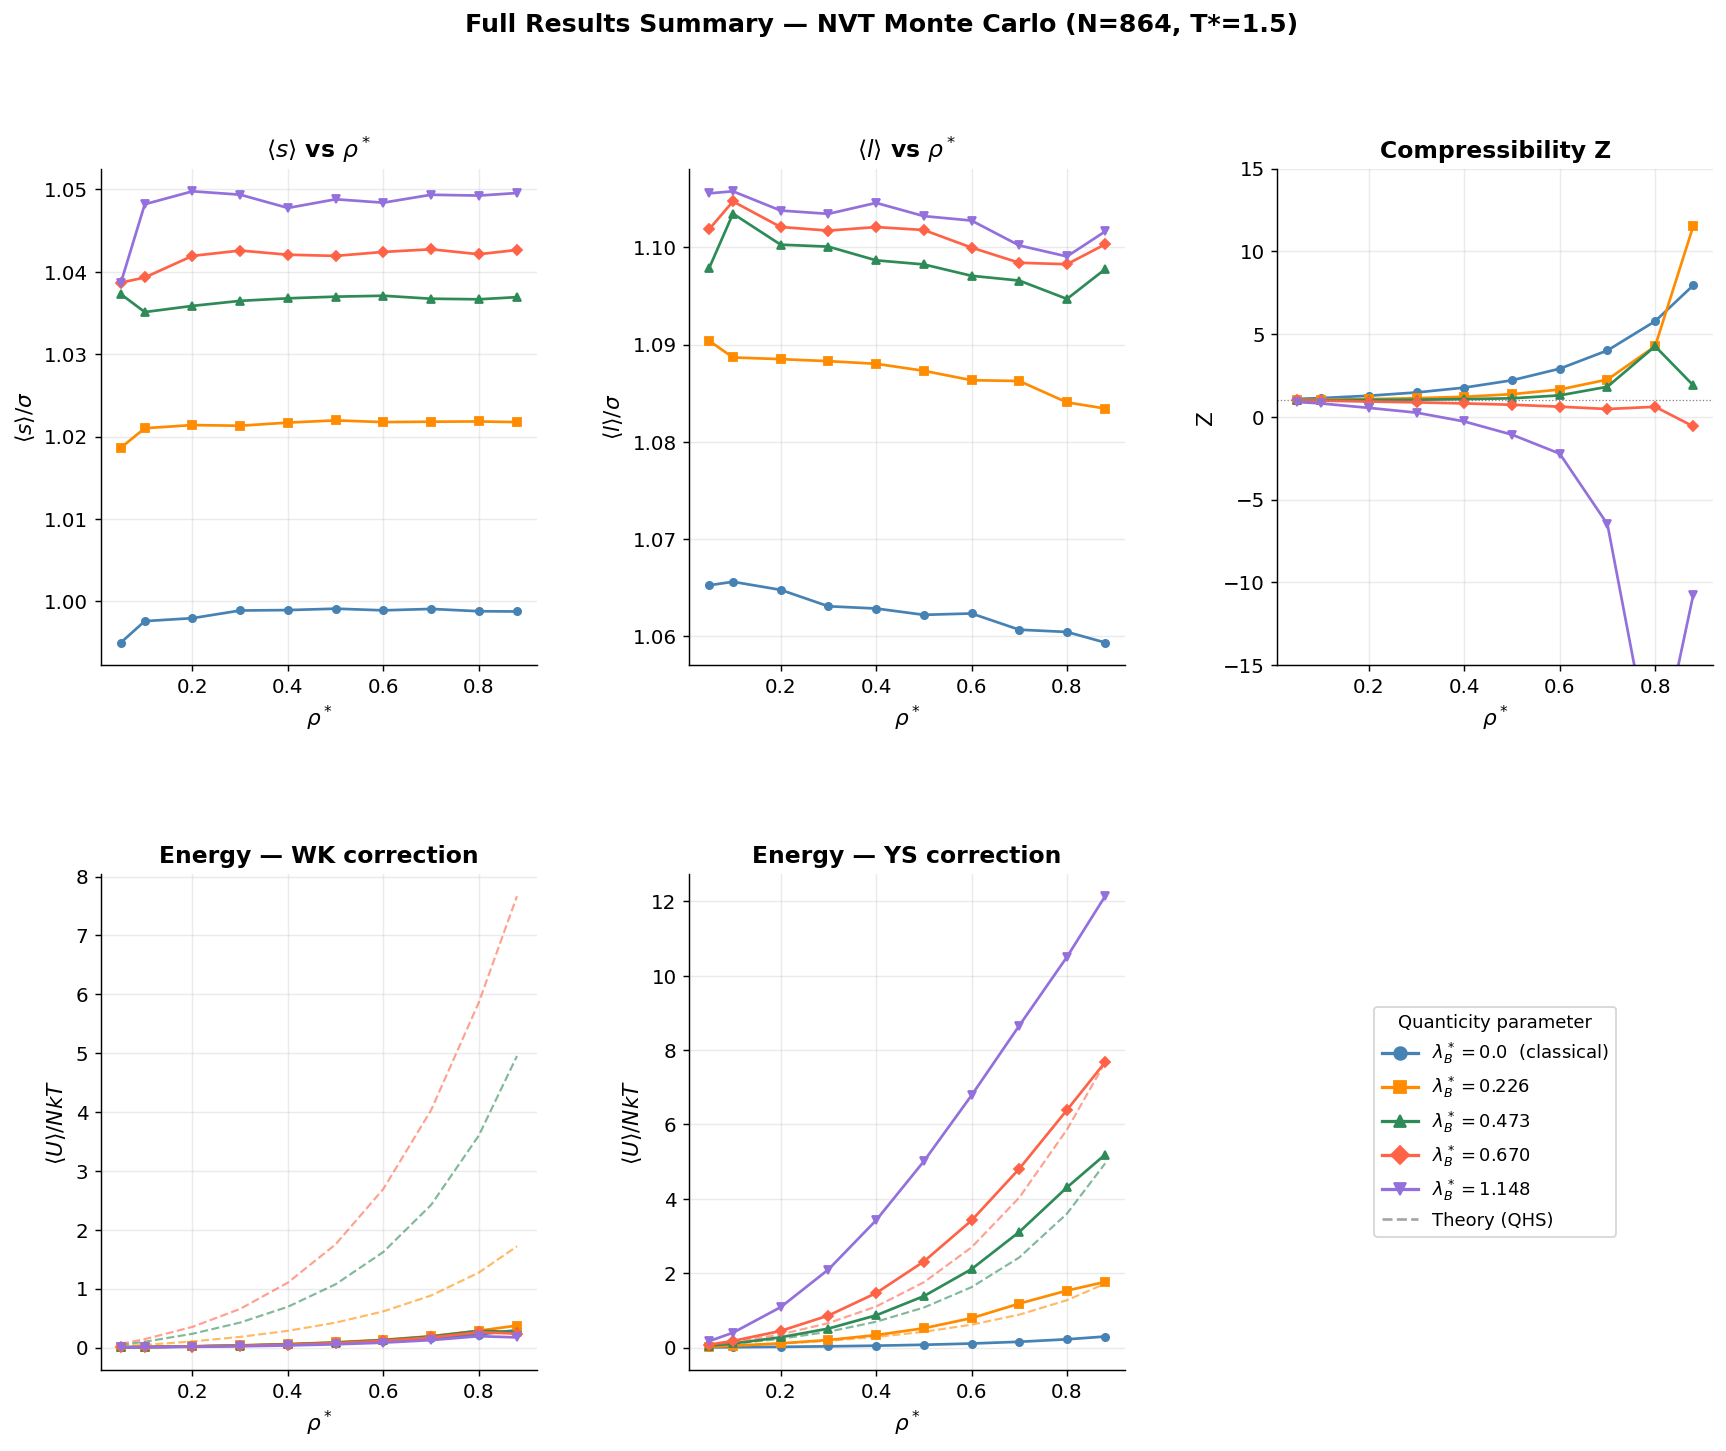

Summary figure saved to data/outputs/full_summary.png


In [10]:
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_s   = fig.add_subplot(gs[0, 0])   # ⟨s⟩ vs rho
ax_l   = fig.add_subplot(gs[0, 1])   # ⟨l⟩ vs rho
ax_Z   = fig.add_subplot(gs[0, 2])   # Z vs rho
ax_wk  = fig.add_subplot(gs[1, 0])   # U_WKS
ax_ys  = fig.add_subplot(gs[1, 1])   # U_YS
ax_leg = fig.add_subplot(gs[1, 2])   # legend panel

for data, lb, label, color, marker in zip(
        ALL_DATA, LB_VALUES, LB_LABELS, COLORS, MARKERS):
    rho = np.array(data['rho'])
    ax_s.plot(rho, data['s'], color=color, marker=marker,
              linewidth=1.5, markersize=4)
    ax_l.plot(rho, data['l'], color=color, marker=marker,
              linewidth=1.5, markersize=4)
    ax_Z.plot(rho, data['Z'], color=color, marker=marker,
              linewidth=1.5, markersize=4)

ax_Z.axhline(1.0, color='gray', linewidth=0.7, linestyle=':')
ax_Z.set_ylim(-15, 15)

ax_s.set_xlabel(r'$\rho^*$'); ax_s.set_ylabel(r'$\langle s \rangle/\sigma$')
ax_s.set_title(r'$\langle s \rangle$ vs $\rho^*$', fontweight='bold')
ax_l.set_xlabel(r'$\rho^*$'); ax_l.set_ylabel(r'$\langle l \rangle/\sigma$')
ax_l.set_title(r'$\langle l \rangle$ vs $\rho^*$', fontweight='bold')
ax_Z.set_xlabel(r'$\rho^*$'); ax_Z.set_ylabel('Z')
ax_Z.set_title('Compressibility Z', fontweight='bold')

# energy panels
ax_wk.plot(rho_u, U_classical, color='steelblue', marker='o',
           linewidth=1.5, markersize=4)
ax_ys.plot(rho_u, U_classical, color='steelblue', marker='o',
           linewidth=1.5, markersize=4)

for lb, color, marker in zip(lb_list, colors4, markers4):
    ax_wk.plot(rho_u, U_WKS[lb], color=color, marker=marker,
               linewidth=1.5, markersize=4)
    ax_ys.plot(rho_u, U_YS[lb], color=color, marker=marker,
               linewidth=1.5, markersize=4)
    u_th = U_QHS[lb]
    if any(v is not None for v in u_th):
        u_th_c = [v for v in u_th if v is not None]
        r_c    = [r for r, v in zip(rho_u, u_th) if v is not None]
        ax_wk.plot(r_c, u_th_c, color=color, linewidth=1.2, linestyle='--', alpha=0.6)
        ax_ys.plot(r_c, u_th_c, color=color, linewidth=1.2, linestyle='--', alpha=0.6)

ax_wk.set_xlabel(r'$\rho^*$'); ax_wk.set_ylabel(r'$\langle U \rangle/NkT$')
ax_wk.set_title('Energy — WK correction', fontweight='bold')
ax_ys.set_xlabel(r'$\rho^*$'); ax_ys.set_ylabel(r'$\langle U \rangle/NkT$')
ax_ys.set_title('Energy — YS correction', fontweight='bold')

# Legend panel
ax_leg.axis('off')
handles = []
for lb, label, color, marker in zip(LB_VALUES, LB_LABELS, COLORS, MARKERS):
    handles.append(Line2D([0], [0], color=color, marker=marker,
                          linewidth=1.8, markersize=7, label=label))
handles.append(Line2D([0], [0], color='gray', linewidth=1.5,
                      linestyle='--', alpha=0.7, label='Theory (QHS)'))
ax_leg.legend(handles=handles, loc='center', fontsize=10, frameon=True,
              title='Quanticity parameter', title_fontsize=10)

plt.suptitle('Full Results Summary — NVT Monte Carlo (N=864, T*=1.5)',
             fontsize=14, fontweight='bold')
plt.savefig('../data/outputs/full_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary figure saved to data/outputs/full_summary.png")

---
## Key Findings

| Observable | Trend with λ_B | Physical interpretation |
|---|---|---|
| ⟨s⟩ | Increases | Quantum effects enlarge effective particle size |
| ⟨l⟩ | Increases | Broader range of attraction |
| ν_R / ν_A | Decreases | Attractive collisions become dominant at high λ_B |
| Z | Decreases, becomes negative | Attractive dominance reduces pressure |
| U (WKS) | Decreases — anomalous | WK correction underestimates energy |
| U (YS) | Increases — correct trend | YS correction matches theory well |

The **Yoon-Scheraga correction** provides significantly better agreement with the
quantum hard-sphere equation of state than the Wigner-Kirkwood correction,
particularly at intermediate and high densities.

The **negative compressibility factor** at high λ_B and high density may signal
proximity to a glass-like phase, consistent with path-integral MC results in the
literature (Sesé & Ledesma, J. Chem. Phys. 1995).

---
*Data from NVT Monte Carlo simulations, N=864, T*=1.5. Original Fortran source in `original_fortran/`. *